# 4 — AutoGluon (AutoML Framework)

This notebook trains and evaluates AutoGluon, an open-source AutoML framework developed by Amazon Web Services. AutoGluon represents the AutoML paradigm — it automates the full machine learning pipeline: model selection, hyperparameter optimisation, feature preprocessing, and ensemble construction.

Unlike XGBoost (a single model type) or TabPFN (a single pre-trained model), AutoGluon trains **multiple heterogeneous models** in parallel — including tree-based models (LightGBM, XGBoost, CatBoost, Random Forest, Extra Trees), neural networks (FastAI, PyTorch MLP), and simple models (KNN, Linear). It then combines their predictions through a learned stacking procedure.



## Setup

Clone the repository and import project modules.

In [1]:
import os, sys

if not os.path.isdir("src"):
    !git clone https://github.com/andreasz24/Thesis-Artifact.git
    %cd Thesis-Artifact
    !pip install -r requirements.txt --quiet

sys.path.insert(0, os.getcwd())
print("Ready! Working directory:", os.getcwd())

Cloning into 'Thesis-Artifact'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 320.24 KiB | 3.68 MiB/s, done.
/content/Thesis-Artifact
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 18.7 MB/

## Load the train/test split

The same preprocessed split used by XGBoost (notebook 2) and TabPFN (notebook 3) is loaded here.

In [2]:
import os, pandas as pd
from src import data, models, evaluation, plotting, config

# If splits.pkl doesn't exist yet, create it automatically
if not os.path.exists(config.SPLITS_PATH):
    print("splits.pkl not found — running preprocessing first...")
    X_train, X_test, y_train, y_test = data.build_splits()
else:
    X_train, X_test, y_train, y_test = data.load_splits()

print('Train:', X_train.shape, '| Test:', X_test.shape)

splits.pkl not found — running preprocessing first...
Unique ratings after collapsing: ['A', 'AA', 'AAA', 'B', 'BB', 'BBB', 'C', 'CC', 'CCC', 'D']
Unmapped ratings: 0
Saved splits -> /content/Thesis-Artifact/outputs/splits.pkl
Train: 6212 rows | Test: 1593 rows
Classes in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Classes in test:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Train: (6212, 16) | Test: (1593, 16)


## How AutoGluon works: Bagging and Stacking

AutoGluon uses two key techniques to improve performance:

### Bagging (Bootstrap Aggregating)

Instead of training one model on the full training set, AutoGluon splits the training data into *k* folds (controlled by `num_bag_folds`). Each base model is trained on *k-1* folds and tested on the remaining fold. This produces **Out-Of-Fold (OOF) predictions** — predictions made on data the model has never seen — for every row in the training set.

Changing the number of bagging folds affects how much data each model is trained on. With 3 folds, each model trains on ~67% of the data. With 8 folds, each model trains on ~87.5%. More folds = more training data per model = more reliable OOF predictions, but slower training.

### Stacked Ensembling

The OOF predictions from all base models become the input for a second layer of models (controlled by `num_stack_levels`). This second layer learns the relationship between what each base model predicted and the actual answer. For example, it might learn that when CatBoost and LightGBM disagree on whether a company is BB or BBB, CatBoost is correct most of the time.

This is particularly valuable for credit ratings because the models can learn about the investment-grade/speculative-grade boundary — when base models disagree near BBB/BB, the stacking layer can learn which disagreement patterns signal genuine uncertainty.

## The 2×2 grid search

Rather than manually selecting a single configuration, we evaluate all combinations of two parameters:

- **`num_bag_folds`** ∈ {3, 8} — controls how many cross-validation folds are used
- **`num_stack_levels`** ∈ {1, 2} — controls how many layers of meta-learning are applied

This gives 4 configurations total. Each configuration is given a time budget of 300 seconds (5 minutes).

**Important:** the best configuration is selected using AutoGluon's internal cross-validation F1 score (`cv_f1_macro`) on the training set — **not** the test set. This is the correct approach for hyperparameter selection because it avoids overfitting to the test data. Test metrics are recorded for reporting only.

### Running the grid search

Each of the 4 configurations trains the full set of AutoGluon base models, bags them, and optionally stacks them. This takes approximately 5 minutes per configuration (~20 minutes total).

In [3]:
grid_df = models.run_autogluon_grid(X_train, y_train, X_test, y_test)
grid_df.to_csv(config.OUTPUTS_DIR/'autogluon_grid_results.csv', index=False)
grid_df


  num_bag_folds=3, num_stack_levels=1


/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


  CV F1 Macro: 0.6033 | Test F1 Macro: 0.2523 | 315.0s

  num_bag_folds=3, num_stack_levels=2
  CV F1 Macro: 0.5836 | Test F1 Macro: 0.2395 | 315.6s

  num_bag_folds=8, num_stack_levels=1
  CV F1 Macro: 0.6127 | Test F1 Macro: 0.2421 | 349.2s

  num_bag_folds=8, num_stack_levels=2
  CV F1 Macro: 0.5895 | Test F1 Macro: 0.2436 | 355.9s


,num_bag_folds,num_stack_levels,cv_f1_macro,test_accuracy,test_f1_macro,test_f1_weighted,train_time_s
0,3,1,0.6033,0.4645,0.2523,0.4532,315.0
1,3,2,0.5836,0.4570,0.2395,0.4419,315.6
2,8,1,0.6127,0.4583,0.2421,0.4433,349.2
3,8,2,0.5895,0.4564,0.2436,0.4381,355.9


### Interpreting the grid results

The differences in test F1 macro across all four configurations are extremely small, suggesting that AutoGluon's predictive performance on this dataset is insensitive to both parameters within the ranges tested.

Some patterns are nonetheless visible:

- **At `num_bag_folds=3`**, adding a second stack level improves performance. The intuition is that with fewer folds, each base model is trained on a smaller share of the data, producing noisier OOF predictions. A second stacking layer compensates by learning the systematic patterns of disagreement and bias in these noisy predictions.

- **At `num_bag_folds=8`**, adding a second stack level slightly reduces performance. Here, the base models are already trained on ~87.5% of the data, producing reliable OOF predictions. A second layer has little noise to correct for, and the additional complexity may introduce overfitting.

### Grid search heatmaps

Three heatmaps visualise the grid results. The first shows the internal CV F1 macro (used for model selection), the second shows the test F1 macro (for reporting), and the third shows training time.

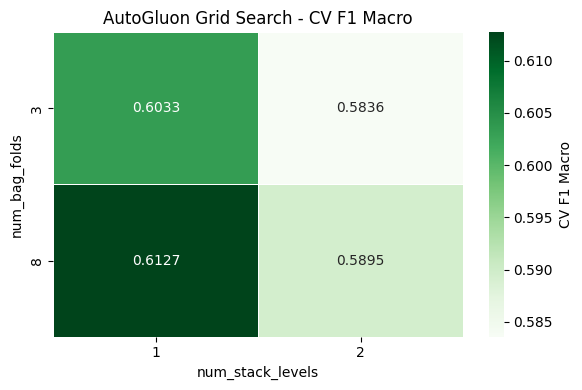

Saved heatmap -> /content/Thesis-Artifact/outputs/ag_grid_cv_f1_macro.png


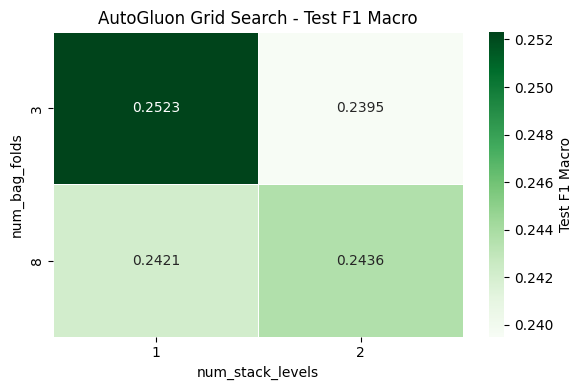

Saved heatmap -> /content/Thesis-Artifact/outputs/ag_grid_test_f1_macro.png


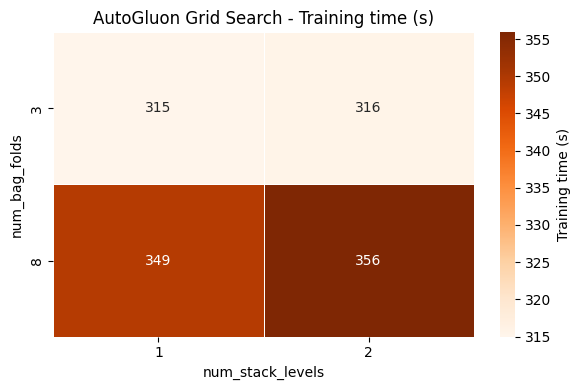

Saved heatmap -> /content/Thesis-Artifact/outputs/ag_grid_train_time.png


In [4]:
plotting.plot_grid_heatmap(grid_df, 'cv_f1_macro', 'CV F1 Macro',
    save_path=config.OUTPUTS_DIR/'ag_grid_cv_f1_macro.png')
plotting.plot_grid_heatmap(grid_df, 'test_f1_macro', 'Test F1 Macro',
    save_path=config.OUTPUTS_DIR/'ag_grid_test_f1_macro.png')
plotting.plot_grid_heatmap(grid_df, 'train_time_s', 'Training time (s)',
    cmap='Oranges', fmt='.0f',
    save_path=config.OUTPUTS_DIR/'ag_grid_train_time.png')

## Final evaluation with the best configuration

The configuration with the highest internal CV F1 macro is selected and retrained for the final evaluation. This produces the headline metrics, per-class report, and confusion matrix that appear in the thesis.

In [ ]:
best = grid_df.loc[grid_df['cv_f1_macro'].idxmax()]
best_folds, best_stacks = int(best['num_bag_folds']), int(best['num_stack_levels'])
print(f'Best config: folds={best_folds}, stacks={best_stacks}')

predictor, results, y_pred = models.train_autogluon_best(
    X_train, y_train, X_test, y_test, best_folds, best_stacks)
evaluation.print_metrics('AutoGluon', results, results['train_time_s'])

Best config: folds=8, stacks=1


Fraction of data from classes with at least 10 examples that will be kept for training models: 0.9977462974887314


## Per-class report

AutoGluon's per-class performance follows the same pattern as XGBoost and TabPFN: reasonable scores on the populated classes (B, BBB, A) and zero on the rare extremes (C, CC, AAA). This consistency across three very different model architectures confirms that the class imbalance is the dominant factor, not the choice of model.

Despite AutoGluon's sophisticated multi-model ensemble, it does not meaningfully outperform the simpler models on any individual class — suggesting that the models within AutoGluon are making correlated errors, limiting the benefit of combining them.

In [ ]:
print(evaluation.per_class_report(y_test, y_pred))

## Confusion matrix

The confusion matrix shows the same modal bias toward BBB observed in XGBoost and TabPFN. Companies rated far from BBB in either direction experience a stronger pull toward it, while classes neighbouring BBB are less affected.

The pattern at the investment-grade / speculative-grade boundary (BBB vs BB) is similar across all three models — the boundary is inherently difficult to classify from financial ratios alone.

In [ ]:
plotting.plot_confusion_pair(y_test, y_pred, 'AutoGluon', cmap='Greens',
    save_path=config.OUTPUTS_DIR/'ag_confusion_matrix.png')

## AutoGluon's internal leaderboard

AutoGluon's leaderboard shows which of its base models performed best individually. This reveals which model families are most suited to this particular classification task.

A notable finding: the weighted ensemble (which combines all base models) underperforms the best individual model (typically CatBoost). This is unusual — ensembles are generally expected to outperform their strongest component. It suggests that the base models are making correlated errors: their misclassifications tend to overlap, so combining their outputs offers little benefit over simply using the single best model.

In [ ]:
predictor.leaderboard(silent=True)

## Feature importance (permutation)

Like TabPFN, AutoGluon's feature importance is computed using the permutation method — shuffling each feature and measuring the drop in performance.

EBITDA Margin and Long-term Debt / Capital typically emerge as the two most important features, consistent with the established view that profitability and leverage are the primary drivers of creditworthiness. This ranking differs from XGBoost's built-in importance (where Pre-Tax Profit Margin ranked highest), reflecting how different model architectures can arrive at similar predictive performance through different feature weightings.

In [1]:
fi = predictor.feature_importance(
    models._to_tabular(X_test, y_test))
plotting.plot_feature_importance(fi['importance'], 'AutoGluon',
    color='seagreen', horizontal=True,
    save_path=config.OUTPUTS_DIR/'ag_feature_importance.png')

NameError: name 'predictor' is not defined

## Summary

AutoGluon requires the least manual configuration of the three models — it automates model selection, hyperparameter tuning, and ensemble construction. However, it takes the longest to train (~300 seconds vs ~30 seconds for XGBoost and ~10 seconds for TabPFN) and delivers performance very close to the baseline.

The grid search reveals that AutoGluon's performance is insensitive to both `num_bag_folds` and `num_stack_levels` within the tested ranges. The finding that the weighted ensemble underperforms the best individual base model suggests that model diversity alone is insufficient when the underlying errors are correlated.

Results are saved to `outputs/autogluon_results.pkl`.